## Dataset creation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

In [2]:
all_dfs = []

# Parameters
E=1
rho=2
L=1

ndt = 3
Nt=300
t_end=3

Nx=100
SS=5
Ntot = Nx + 2*SS
nodes = np.arange(SS,Ntot-SS)

v     = np.sqrt(E/rho)    # wave speed [m/s]

# Grid
x  = np.linspace(0, L, Nx)
dx = x[1] - x[0]
dt = t_end / Nt

# Stable behaviour
CFL = v * dt / dx
assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : unstable scheme"

N=5
AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(1, 10, N).round(1).tolist()

n_sims = len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
for idx, (A, omega) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    
    t_pulse = 2 * np.pi / omega 

    def u_right(t): 
        if t < t_pulse:
            return A* np.sin(omega * t)
        else:
            return 0.0  

    u=np.zeros(Ntot)
    u_dot=np.zeros(Ntot)
    u_1=np.zeros(Ntot)
    x_stencil = np.arange(SS) * dx          
    u_xx = np.zeros(Ntot)

    u_storage = np.zeros((Nt+1,Ntot))
    u_xx_storage=np.zeros((Nt,Ntot))
    delta_u_storage=np.zeros((Nt,Ntot))
    u_storage[0]=u.copy()
    ux_minus_storage = np.zeros((Nt, Ntot))
    ux_plus_storage  = np.zeros((Nt, Ntot))

    i_left = SS
    i_right = Ntot - SS
    rows = []

    for n in range (Nt):
        t=n*dt

        u_xx[SS:Ntot-SS+1] = (u[SS-1:Ntot-SS] -2*u[SS:Ntot-SS+1] +u[SS+1:Ntot-SS+2]) / dx**2

        Y_left  = u[nodes[None, :] + np.arange(-SS, 0)[:, None]]    
        Y_right = u[nodes[None, :] + np.arange(1, SS+1)[:, None]]  

        ux_minus_storage[n, nodes] = np.polyfit(x_stencil, Y_left,  1)[0]
        ux_plus_storage[n,  nodes] = np.polyfit(x_stencil, Y_right, 1)[0]

        u_new = np.zeros(Ntot)

        u_new[SS:Ntot-SS+1] = (2.0 * u[SS:Ntot-SS+1] - u_1[SS:Ntot-SS+1] + CFL**2 * (u[SS-1:Ntot-SS] - 2.0 * u[SS:Ntot-SS+1] + u[SS+1:Ntot-SS+2]))

        u_new[:i_left+1]  = 0.0
        u_new[i_right:] = u_right(t + dt)

        u_xx_storage[n]    = u_xx

        u_1=u.copy()
        u   = u_new
        u_storage[n + 1] = u.copy()
        
    for n in range(ndt, Nt-ndt-1):
        row={"A":A,"omega":omega, "n_step":n}

        #Inputs
        u_dot_ndt = (u_storage[n] - u_storage[n-ndt]) / (ndt*dt)
        row["u_dot"] = u_dot_ndt[nodes]
        row["u_xx"]  = u_xx_storage[n, nodes]
        row["ux-"]   = ux_minus_storage[n, nodes]
        row["ux+"]   = ux_plus_storage[n, nodes]
        
        #Ouputs
        row["delta_u"]=u_storage[n+ndt,nodes]-u_storage[n,nodes]
        
        rows.append(pd.DataFrame(row))
    

    all_dfs.append(pd.concat(rows, ignore_index=True))



# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))


Empty DataFrame
Columns: [A, omega, n_step, u_dot, u_xx, ux-, ux+, delta_u]
Index: []


In [3]:
rng = np.random.default_rng(seed=42)

steps   = np.sort(df["n_step"].unique())
n_steps = len(steps)

n_train = int(0.60 * n_steps)
n_val   = int(0.20 * n_steps)

train_steps = set(steps[:n_train])
val_steps   = set(steps[n_train:n_train + n_val])

def assign_split(row):
    if row["n_step"] in train_steps: return "train"
    if row["n_step"] in val_steps:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Split distribution:")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} rows  ({100*n/len(df):.1f} %)")

Split distribution:
  train :  437,500 rows  (59.7 %)
  val   :  145,000 rows  (19.8 %)
  test  :  150,000 rows  (20.5 %)


## Normalization (z-score)

In [4]:
INPUTS = ["u_dot", "u_xx", "ux-", "ux+"]
OUTPUTS = ["delta_u"]

# Train mask: compute the stats on the train set only
train_mask = df["split"] == "train"

# Compute mean/std on the train set only
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # avoid division by zero

# Apply normalization to the whole dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Normalization statistics (computed on train):")
print(norm_stats.round(6))

Normalization statistics (computed on train):
             mean       std
u_dot   -0.002110  0.180110
u_xx    -0.000728  6.863850
ux-      0.007353  0.246027
ux+      0.006440  0.245969
delta_u -0.000081  0.005447


---
## Save

In [5]:
COLS_ORDER = (
    INPUTS                                   # raw inputs
    + [c + "_n" for c in INPUTS]             # normalized inputs
    + OUTPUTS                                # raw outputs
    + [c + "_n" for c in OUTPUTS]            # normalized outputs
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset saved: wave_beam_dataset.csv")
print(f"  {len(df):,} rows x {len(df.columns)} columns")

# Normalization stats - to be reloaded in notebooks 2 and 3
norm_stats.to_csv("norm_stats.csv")
print(f"Normalization stats saved: norm_stats.csv")

Dataset saved: wave_beam_dataset.csv
  732,500 rows x 11 columns
Normalization stats saved: norm_stats.csv


In [6]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "SS":SS,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Parameters saved: params_simulation.json")

Parameters saved: params_simulation.json


In [7]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
SS=p["SS"]
INPUTS    = p["INPUTS"]
OUTPUTS    = p["OUTPUTS"]

#print(INPUTS)

---
## 1. Parameters

In [8]:
# Files produced by notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Network architecture
HIDDEN_SIZE = 50    # number of neurons per hidden layer
N_LAYERS    = 2     # number of hidden layers

# Training
LEARNING_RATE = 1e-3
N_EPOCHS      = 10
BATCH_SIZE    = 512

---
## 2. Data loading

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Load the dataset and the normalization stats
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} rows")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Normalized columns
#INPUTS_N = [f"u_dot_{k:+d}_n" for k in range(-SS, SS+1)] + [f"u_xx_{k:+d}_n" for k in range(-SS, SS+1)]
INPUTS_N = [c + "_n" for c in INPUTS]  
OUTPUTS_N = ["delta_u_n"]

# Extract train / val using the dataset split column
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

print(f"\nTrain : {len(X_train):,} examples")
print(f"Val   : {len(X_val):,} examples")

# Convert to PyTorch tensors and build the DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)

Dataset : 732,500 rows
Splits  : {'train': 437500, 'test': 150000, 'val': 145000}

Train : 437,500 examples
Val   : 145,000 examples


---
## 3. Network definition


In [10]:
class Network(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_size, n_layers):
        super().__init__()

        layers = []
        input_size = n_inputs

        for _ in range(n_layers):
            layers.append(nn.Linear(input_size, hidden_size))  # linear layer
            layers.append(nn.Tanh())                              # non-linear activation
            input_size = hidden_size

        layers.append(nn.Linear(hidden_size, n_outputs))  # output layer

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


model = Network(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_size = HIDDEN_SIZE,
    n_layers    = N_LAYERS,
)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nNumber of parameters: {n_params:,}")

Network(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=1, bias=True)
  )
)

Number of parameters: 2,851


---
## 4. Training

Epoch    2/10  -  train: 0.0077  |  val: 0.0351  
Epoch    4/10  -  train: 0.0058  |  val: 0.0303  
Epoch    6/10  -  train: 0.0049  |  val: 0.0322  
Epoch    8/10  -  train: 0.0044  |  val: 0.0405  
Epoch   10/10  -  train: 0.0040  |  val: 0.0404  


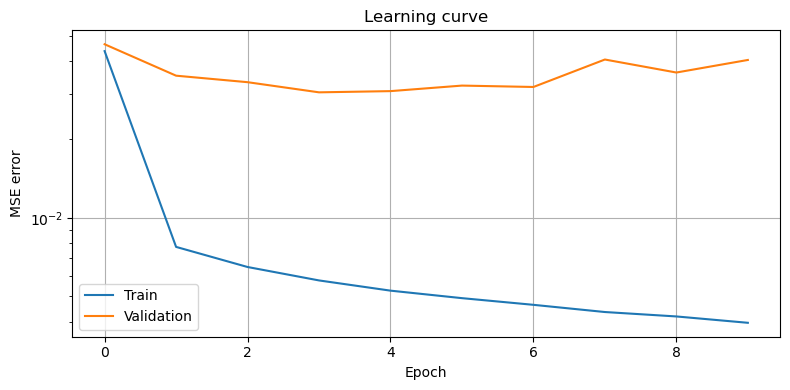

Best model reloaded - minimum val: 0.030331


In [11]:
criterion  = nn.MSELoss()   # mean squared error
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)

history_train = []
history_val   = []

best_val = float("inf")   # initialize to the worst possible score
patience_counter = 0          # (kept for later use)

for epoch in range(1, N_EPOCHS + 1):

    # Training phase
    model.train()
    loss_train = 0.0       # initialization of training loss
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()                       # reset gradients to zero
        prediction = model(X_batch)                 # forward pass
        loss      = criterion(prediction, y_batch)  # loss
        loss.backward()                             # backpropagation
        optimizer.step()                            # update weights
        loss_train += loss.item()
    loss_train /= len(train_loader)

    # Validation phase: a single forward pass over the whole val set
    model.eval()
    with torch.no_grad():
        pred_val = model(torch.tensor(X_val)).numpy()

    # Global loss
    loss_val = ((pred_val - y_val)**2).mean()
    scheduler.step(loss_val)

    # Record losses
    history_train.append(loss_train)
    history_val  .append(loss_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  -  "
            f"train: {loss_train:.4f}  |  "
            f"val: {loss_val:.4f}  ")
    
    # If validation improved, save this model
    if loss_val < best_val:
        best_val = loss_val
        torch.save(model.state_dict(), "model.pth")   # overwrite with the best so far

# Learning curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_train, label="Train")
ax.plot(history_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("MSE error")
ax.set_title("Learning curve")
ax.set_yscale("log")
ax.legend() ; ax.grid(True)
plt.tight_layout() ; plt.show()

# Reload the best model found during training
model.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Best model reloaded - minimum val: {best_val:.6f}")

---
## Verification

Evaluation on 150,000 test samples


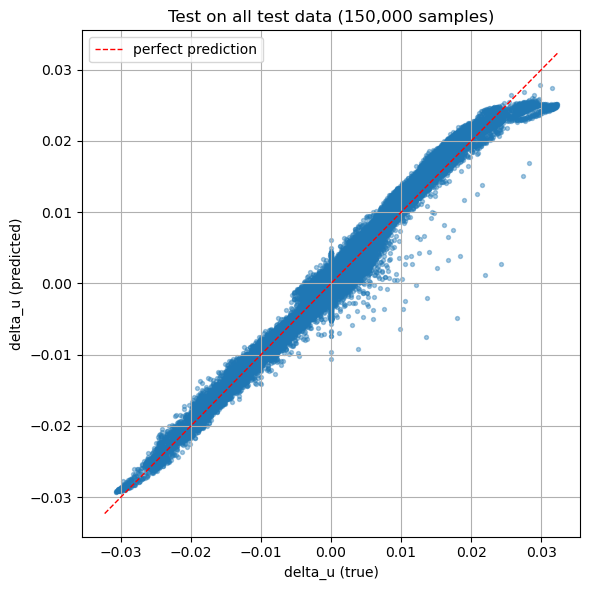

MSE : 7.6483e-07   |   R² : 0.9802


In [12]:
# --- 1. Filter the test rows of the dataset ---
df = pd.read_csv(DATASET_FILE)                              # remove if df is already loaded
df_test = df[df["split"] == "test"].reset_index(drop=True)
print(f"Evaluation on {len(df_test):,} test samples")

# --- 3. Extract inputs (already normalized in the CSV) and the true output ---
X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test["delta_u"].values                          # unnormalized ground truth

# --- 4. Prediction ---
model.eval()
with torch.no_grad():
    y_pred_n = model(torch.tensor(X_new)).numpy().squeeze()

# Denormalize the output
mean_du = norm_stats.loc["delta_u", "mean"]
std_du  = norm_stats.loc["delta_u", "std"]
y_pred = y_pred_n * std_du + mean_du

# --- 5. Visualization ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.4, s=8)
lim = max(abs(y_true).max(), abs(y_pred).max())
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="perfect prediction")
ax.set_xlabel("delta_u (true)")
ax.set_ylabel("delta_u (predicted)")
ax.set_title(f"Test on all test data ({len(df_test):,} samples)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

mse = ((y_pred - y_true)**2).mean()
r2  = 1 - mse / y_true.var()
print(f"MSE : {mse:.4e}   |   R² : {r2:.4f}")

(100, 4)
(100,)
0.0021541669993894175
0.017525583003589418
ndt =  3


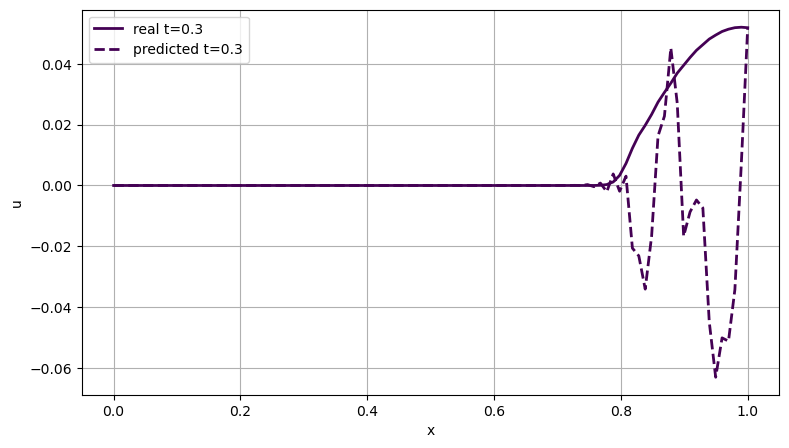

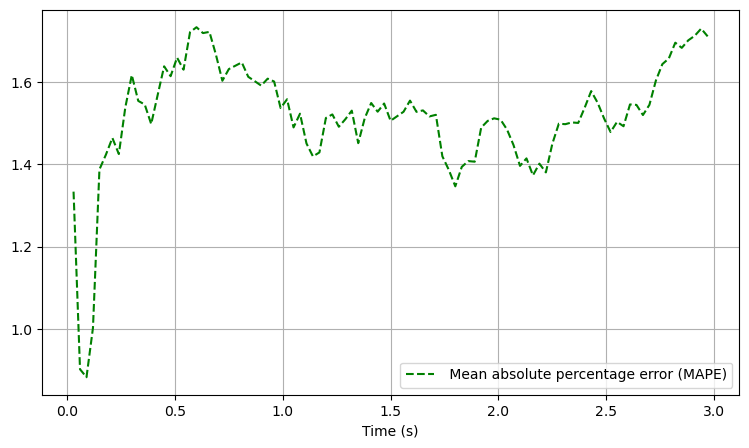

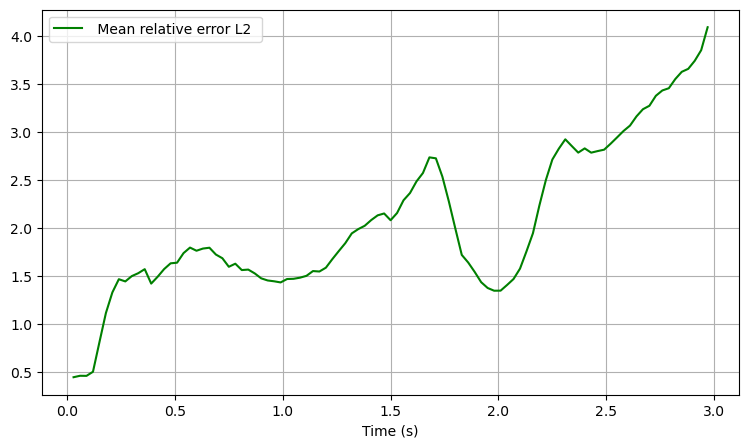

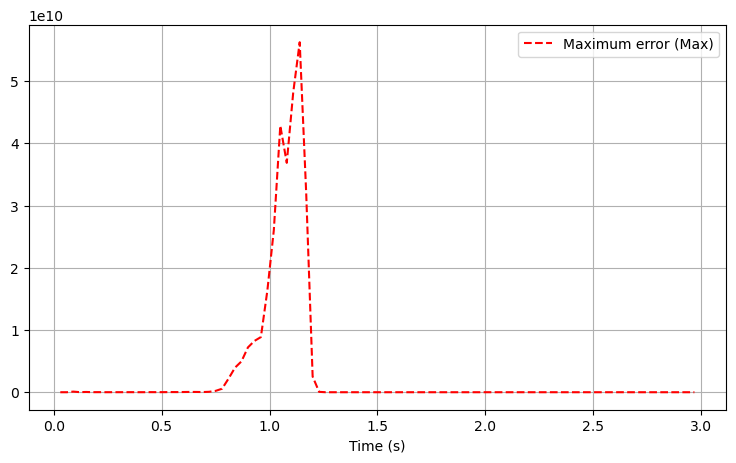

In [14]:
# Roll Out

import time
from scipy.sparse import diags


A = AMPLITUDES[2]
omega = PULSATIONS[2]

dx = L / (Nx - 1)
dt = t_end / Nt
t_list = [0.3]
x = np.linspace(0, L, Nx)

stats_normalization = {}
for name in INPUTS + OUTPUTS:
    stats_normalization[name] = {
        "mean": norm_stats.loc[name, "mean"],
        "std" : norm_stats.loc[name, "std"]
    }

mu_du = stats_normalization[OUTPUTS[0]]["mean"]
sd_du = stats_normalization[OUTPUTS[0]]["std"]

# Local slope weights (same as the dataset)
x_left  = -np.arange(SS, 0, -1) * dx
x_right =  np.arange(1, SS+1)   * dx
w_left  = (x_left  - x_left.mean())  / ((x_left  - x_left.mean())**2).sum()
w_right = (x_right - x_right.mean()) / ((x_right - x_right.mean())**2).sum()

t_pulse = 2 * np.pi / omega
def u_right(t):
    return A * np.sin(omega * t) if t < t_pulse else 0.0

# =====================================================
# 1) TRUE simulation (physics)
# =====================================================

start_time_phys = time.perf_counter()

v   = np.sqrt(E / rho)        # rho=2 here, consistent with the dataset
CFL = v * dt / dx

u   = np.zeros(Nx)
u_2 = np.zeros(Nx)
real = {0.0: u.copy()}
for n in range(Nt):
    t = n * dt
    u_new = np.zeros(Nx)
    u_new[1:-1] = 2*u[1:-1] - u_2[1:-1] + CFL**2 * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0]  = 0.0
    u_new[-1] = u_right(t+dt)
    u_2 = u.copy()
    u   = u_new
    real[round((n+1)*dt, 5)] = u.copy()

time_phys = time.perf_counter() - start_time_phys

# =====================================================
# 2) PREDICTED simulation (network)
# =====================================================

start_time_pred = time.perf_counter()

Ntot=Nx+2*SS
u   = np.zeros(Ntot)
u_ndt = np.zeros(Ntot)
u_xx = np.zeros(Ntot)

pred = {0.0: u[SS:Nx+SS].copy()}

nodes = np.arange(SS,Nx+SS)
i_left = SS
i_right = Nx + SS - 1

# Error initialization

error_mape=[]
error_max=[]
error_l2_rel=[]
sim_times = []

def l2_rel(u_pred, u_real, eps=1e-12):
    return np.linalg.norm(u_pred - u_real) / (np.linalg.norm(u_real) + eps)

def smape (prediction, target,eps=1e-12):
    mask = target!= 0
    num=np.abs(target[mask]-prediction[mask])*2
    den=np.abs(target[mask]) +np.abs(prediction[mask])+eps
    return np.mean((num/den))

def errormax(target, prediction,eps=1e-12):
    num = np.abs(target-prediction)
    den = np.maximum(np.abs(target), eps)
    return np.max((num/den))

def slopes(u):
    # local left/right slopes over the whole padded field (same weights as the dataset)
    ux_minus = np.zeros(Ntot)
    ux_plus  = np.zeros(Ntot)
    for o in range(1, SS+1):
        ux_minus[SS:Nx+SS] += w_left[SS-o] * u[SS-o : Nx+SS-o]
    for m in range(1, SS+1):
        ux_plus[SS:Nx+SS]  += w_right[m-1] * u[SS+m : Nx+SS+m]
    return ux_minus, ux_plus

def build_input(u_dot, u_xx, ux_minus, ux_plus):
    fields = {"u_dot": u_dot, "u_xx": u_xx, "ux-": ux_minus, "ux+": ux_plus}
    e = np.zeros((len(nodes), len(INPUTS)), dtype=np.float32)
    for idx, name in enumerate(INPUTS):
        mu = stats_normalization[name]["mean"]
        sd = stats_normalization[name]["std"]
        e[:, idx] = (fields[name][nodes] - mu) / sd
    return e

# Rest bias: at u=0 all stencils are 0, so the network outputs the same constant on every node
with torch.no_grad():
    z = np.zeros(Ntot)
    inp_rest = build_input(z, z, z, z)
    out_rest = model(torch.tensor(inp_rest)).numpy().ravel()
bias_rest = (out_rest * sd_du + mu_du)[0]    

# Roll out algorithm

# Autoregressive rollout: each network call advances the whole field by ndt time steps
for n in range(0, Nt-ndt-1, ndt):
    
    t = n * dt
    t_next = round((n+ndt)*dt, 5)

    u[:i_left]   = 0.0            
    u[i_right+1:] = u[i_right]    
    
    u_xx[1:-1] = (u[2:] + u[:-2] - 2*u[1:-1] ) / dx**2
    
    u_dot = (u - u_ndt) / (ndt*dt)                            

    ux_minus, ux_plus = slopes(u)
    inp = build_input(u_dot, u_xx, ux_minus, ux_plus)
    if n == 0 : print(inp.shape)
    with torch.no_grad():
        out = model(torch.tensor(inp)).numpy().ravel()
    if n == 0 : print(out.shape)
    delta_u = out * sd_du + mu_du - bias_rest

    u_new = np.zeros(Ntot)
    u_new[nodes] = u[nodes] + delta_u
    
    # Impose ONLY the two physical boundary nodes (do not overwrite the ghost band)
    u_new[i_left]  = 0.0
    u_new[i_right] = u_right(t_next)
    
    u_ndt = u.copy()
    u   = u_new

    u_phys = u_new[nodes]

    pred[t_next] = u_phys.copy()

    # Error computing
    u_real_now=real[t_next]

    sim_times.append(t_next)
    error_mape.append(smape(u_phys, u_real_now))
    error_max.append(errormax(u_real_now, u_phys))  
    error_l2_rel.append(l2_rel(u_phys, u_real_now))

time_pred = time.perf_counter() - start_time_pred

# Duration of the methods

print(time_phys)
print(time_pred)

# =====================================================
# 3) Plots
# ================================================

print( "ndt = ", ndt)

plt.figure(figsize=(9, 5))
for t, c in zip(t_list, plt.cm.viridis(np.linspace(0, 0.85, len(t_list)))):
    kr = min(real, key=lambda k: abs(k - t))
    kp = min(pred, key=lambda k: abs(k - t))
    plt.plot(x, real[kr], color=c, lw=2, label=f"real t={t}")
    plt.plot(x, pred[kp], color=c, lw=2, ls="--", label=f"predicted t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)

# Plotting errors

plt.figure(figsize=(9, 5))
plt.plot(sim_times,error_mape, label=" Mean absolute percentage error (MAPE)", color="green", lw=1.5, ls="--")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(sim_times,error_l2_rel, label=" Mean relative error L2 ", color="green", lw=1.5, ls="-")
plt.legend()
plt.grid(True)
plt.xlabel("Time (s)")

plt.figure(figsize=(9, 5))
plt.plot(sim_times, error_max, label="Maximum error (Max)", color="red", lw=1.5, ls="--")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True)

plt.show()